In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 2.59G/2.59G [00:26<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2
Contents of base_path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions):
['2']
Contents of path (/root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2):
['masks', 'GroundTruth.csv', 'images']


Checking for images in: /root/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2/images

Found 10015 image files in total. Displaying samples:


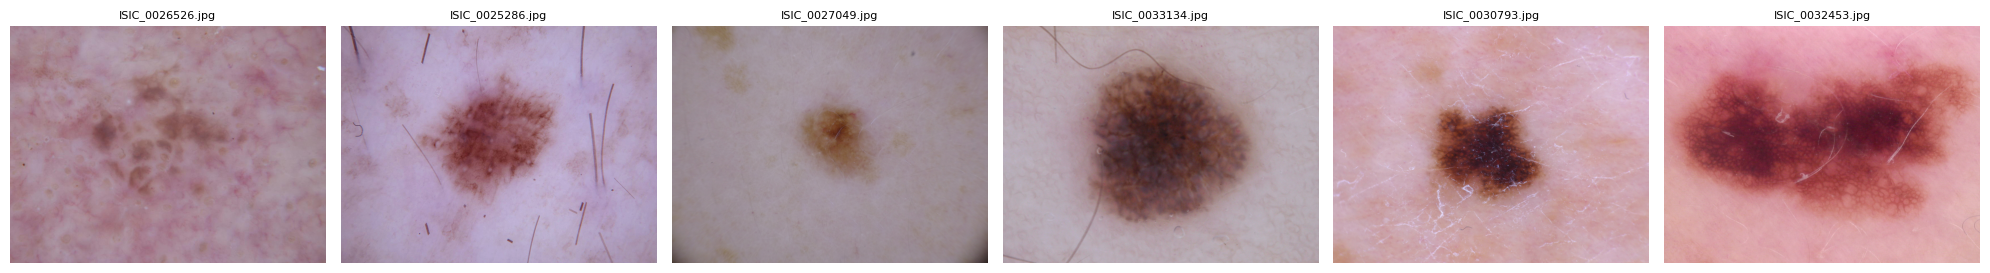

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'images')

print(f"Checking for images in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    # Scan through the images folder directly
    for root, dirs, files in os.walk(image_root_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select up to 6 samples to display
        num_samples = min(len(all_image_paths), 6)
        samples_to_display = all_image_paths[:num_samples]

        fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
        if num_samples == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show the filename
                axes[i].set_title(os.path.basename(img_path), fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the 'images' folder.")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Path to the metadata file containing labels
metadata_path = os.path.join(path, 'GroundTruth.csv')

if os.path.exists(metadata_path):
    # Read data from CSV file
    df = pd.read_csv(metadata_path)

    # Split dataset into train (80%) and test (20%)
    # random_state=42 ensures reproducibility
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print(f"Total samples: {len(df)}")
    print(f"Training set size: {len(train_df)} (80%)")
    print(f"Testing set size: {len(test_df)} (20%)")

    # Display first few rows of the training set
    display(train_df.head())
else:
    # If no metadata file exists, split based on image paths
    train_paths, test_paths = train_test_split(all_image_paths, test_size=0.2, random_state=42)
    print(f"GroundTruth.csv not found. Splitting directly from image file list:")
    print(f"Training image count: {len(train_paths)}")
    print(f"Testing image count: {len(test_paths)}")

Total samples: 10015
Training set size: 8012 (80%)
Testing set size: 2003 (20%)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
6582,ISIC_0030888,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7194,ISIC_0031500,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9446,ISIC_0033752,1.0,0.0,0.0,0.0,0.0,0.0,0.0
533,ISIC_0024839,0.0,0.0,0.0,0.0,1.0,0.0,0.0
132,ISIC_0024438,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import tensorflow as tf

# Check for GPU availability
print("TensorFlow version:", tf.__version__)
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"GPU is available: {physical_devices}")
    # Set memory growth to avoid allocating all memory at once
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("GPU is NOT available. Using CPU instead.")

TensorFlow version: 2.20.0
GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 7 # Based on GroundTruth.csv columns (MEL, NV, BCC, AKIEC, BKL, DF, VASC)

# Prepare Data Generators
# Note: image names in CSV need the file extension for ImageDataGenerator
train_df['image_id'] = train_df['image'] + '.jpg'
test_df['image_id'] = test_df['image'] + '.jpg'

class_columns = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.1)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_root_dir,
    x_col="image_id",
    y_col=class_columns,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training"
)

val_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_root_dir,
    x_col="image_id",
    y_col=class_columns,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation"
)

# Build MobileNet Model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Found 7211 validated image filenames.
Found 801 validated image filenames.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting training...
Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 137s 426ms/step - accuracy: 0.7426 - loss: 0.7729 - val_accuracy: 0.6929 - val_loss: 1.8085
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 60s 263ms/step - accuracy: 0.8110 - loss: 0.5251 - val_accuracy: 0.7391 - val_loss: 0.8471
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 61s 268ms/step - accuracy: 0.8519 - loss: 0.4264 - val_accuracy: 0.7029 - val_loss: 0.9460
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 64s 284ms/step - accuracy: 0.8805 - loss: 0.3452 - val_accuracy: 0.7965 - val_loss: 0.6180
Epoch 5/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 289ms/step - accuracy: 0.9017 - loss: 0.2729 - val_accuracy: 0.7828 - val_loss: 0.8897
Epoch 6/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 288ms/step - accuracy: 0.9235 - loss: 0.2186 - val_accuracy: 0.6829 - val_loss: 1.2222
Epoch 7/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 64s 282ms/step - accuracy:

In [ ]:
# Summarize Training Results
loss, accuracy = model.evaluate(val_generator)
print(f"Final Validation Loss: {loss:.4f}")
print(f"Final Validation Accuracy: {accuracy:.4f}")

model.summary()

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step - accuracy: 0.8090 - loss: 0.6736
Final Validation Loss: 0.6736
Final Validation Accuracy: 0.8090


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 12,813,143 (48.88 MB)

 Trainable params: 4,263,751 (16.26 MB)

 Non-trainable params: 21,888 (85.50 KB)

 Optimizer params: 8,527,504 (32.53 MB)

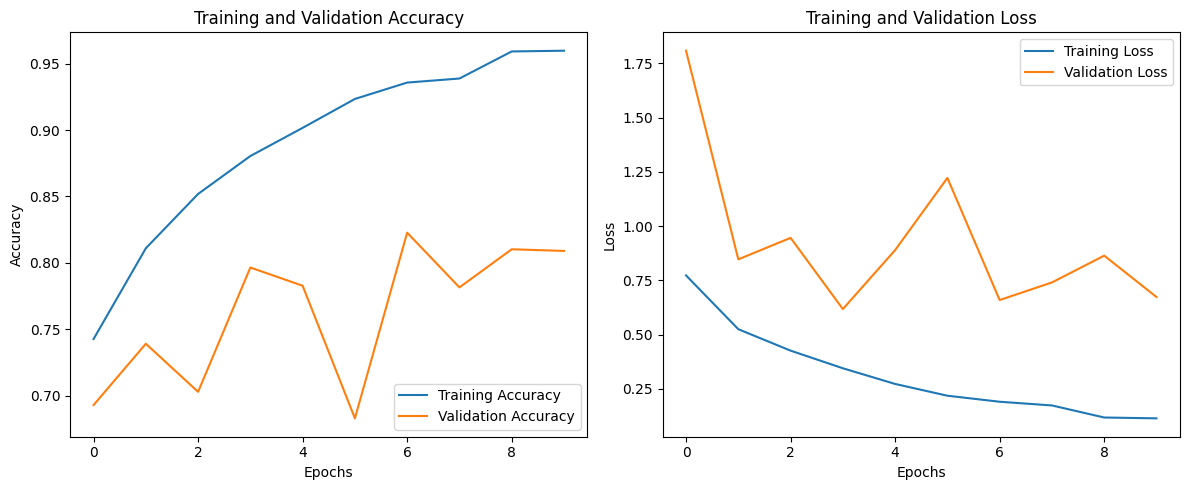

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy/Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()